<a href="https://colab.research.google.com/github/KAguilar93/finance_forecaster/blob/development-staging/notebooks/finance_forecaster_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finance Forecaster Notebook

This version keeps outputs in notebook variables and displays plots inline instead of saving files to folders.


## Imports


In [4]:
# Install the ARCH library for GARCH modeling
# Required for conditional volatility estimation using GARCH(1,1) model
!pip install arch

In [5]:
# ========== Core Data & Computation Libraries ==========
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display

# ========== Time Series & Volatility Analysis ==========
from arch import arch_model  # GARCH modeling for volatility forecasting
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.arima.model import ARIMA  # ARIMA models for return forecasting
from statsmodels.tsa.stattools import adfuller, kpss  # Stationarity tests

# ========== Machine Learning & Classification ==========
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler  # Feature scaling for LSTM
from sklearn.utils.class_weight import compute_class_weight  # Handle imbalanced data

# ========== Deep Learning: LSTM Neural Network ==========
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

## Parameters


In [6]:
# ========== Main Configuration Parameters ==========

# Stock ticker symbol to analyze
ticker = 'QQQ'

# Historical data period
start = '2015-01-01'  # Training data start date
end = '2025-01-01'    # Training data end date

# Standardize ticker to uppercase
ticker = ticker.upper()

## Data download helpers


In [7]:
def download_stock_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Download historical price and volume data for a given ticker using yfinance.

    Args:
        ticker: Stock symbol (e.g., 'QQQ')
        start_date: Start date in 'YYYY-MM-DD' format
        end_date: End date in 'YYYY-MM-DD' format

    Returns:
        DataFrame with 'price' and 'volume' columns, cleaned of NaN values
    """
    # Fetch OHLCV data from Yahoo Finance
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f'No data found for ticker: {ticker}')

    # Handle multi-index columns (when multiple tickers are requested) vs single column case
    if isinstance(data.columns, pd.MultiIndex):
        price = data['Close']
        volume = data['Volume']
        if isinstance(price, pd.DataFrame):
            price = price.iloc[:, 0]  # Extract first ticker's data if multiple
        if isinstance(volume, pd.DataFrame):
            volume = volume.iloc[:, 0]
    else:
        price = data['Close']
        volume = data['Volume']

    # Create clean DataFrame with price and volume
    df = pd.DataFrame({'price': price, 'volume': volume})
    df.dropna(inplace=True)
    return df


def download_external_market_features(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Download market index and sector ETF data to create macro features.
    Computes relative strength indicators between different asset classes.

    Args:
        start_date: Start date in 'YYYY-MM-DD' format
        end_date: End date in 'YYYY-MM-DD' format

    Returns:
        DataFrame with market features including close prices, returns, and ratios
    """
    # Define ticker symbols for major market indices and sector ETFs
    tickers = {
        'vix': '^VIX',           # Volatility Index
        'spy': 'SPY',            # S&P 500
        'iwm': 'IWM',            # Small cap (Russell 2000)
        'xlk': 'XLK',            # Technology sector
        'xlf': 'XLF',            # Financial sector
        'xli': 'XLI',            # Industrial sector
        'xly': 'XLY',            # Consumer discretionary sector
        'xlp': 'XLP',            # Consumer staples sector
        'tlt': 'TLT',            # Long-term Treasury bonds
        'hyg': 'HYG',            # High-yield corporate bonds
        'uup': 'UUP',            # US Dollar Index
        'gld': 'GLD',            # Gold ETF
        'tnx': '^TNX',           # 10-year Treasury yield
    }
    feature_data = pd.DataFrame()

    # Download data for each ticker and compute log returns
    for name, ticker_symbol in tickers.items():
        data = yf.download(ticker_symbol, start=start_date, end=end_date, auto_adjust=True, progress=False)
        if data.empty:
            print(f'Warning: No data found for {ticker_symbol}')
            continue

        # Extract close price handling multi-index case
        if isinstance(data.columns, pd.MultiIndex):
            close = data['Close']
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
        else:
            close = data['Close']

        # Store both close price and log return
        feature_data[f'{name}_close'] = close
        feature_data[f'{name}_return'] = np.log(close).diff()

    feature_data.dropna(inplace=True)

    # ========== Compute Relative Strength Ratios ==========
    # These ratios capture market sentiment and sector rotations
    feature_data['iwm_spy_relative_strength'] = feature_data['iwm_close'] / feature_data['spy_close']
    feature_data['qqq_spy_market_strength'] = feature_data['xlk_close'] / feature_data['spy_close']
    feature_data['tech_vs_staples'] = feature_data['xlk_close'] / feature_data['xlp_close']
    feature_data['discretionary_vs_staples'] = feature_data['xly_close'] / feature_data['xlp_close']
    feature_data['financials_vs_market'] = feature_data['xlf_close'] / feature_data['spy_close']
    feature_data['industrials_vs_market'] = feature_data['xli_close'] / feature_data['spy_close']
    feature_data['credit_risk_appetite'] = feature_data['hyg_close'] / feature_data['tlt_close']
    feature_data['gold_vs_market'] = feature_data['gld_close'] / feature_data['spy_close']
    return feature_data

## Feature and test helpers


In [8]:
def add_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute log prices, log returns, and squared log returns.
    Log returns are useful for capturing percentage changes and are additive across time periods.
    Squared returns capture volatility clustering behavior.
    """
    df = df.copy()
    df['log_price'] = np.log(df['price'])
    df['log_return'] = df['log_price'].diff()
    df['log_return_squared'] = df['log_return'] ** 2  # Used for GARCH volatility modeling
    return df


def run_adf_test(series: pd.Series, series_name: str) -> dict:
    """
    Run Augmented Dickey-Fuller test to check for stationarity.
    Stationarity is important for ARIMA and GARCH models to work effectively.
    p-value <= 0.05 indicates the series is stationary (reject null hypothesis).
    """
    result = adfuller(series.dropna())
    return {
        'series': series_name,
        'test': 'ADF',
        'statistic': result[0],
        'p_value': result[1],
        'lags_used': result[2],
        'observations': result[3],
        'stationary_result': 'Stationary' if result[1] <= 0.05 else 'Non-stationary',
    }


def run_kpss_test(series: pd.Series, series_name: str) -> dict:
    """
    Run KPSS test as complement to ADF test for stationarity.
    KPSS has opposite null hypothesis: assumes stationarity.
    p-value > 0.05 indicates the series is stationary (fail to reject null hypothesis).
    """
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        statistic, p_value, lags, critical_values = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'series': series_name,
        'test': 'KPSS',
        'statistic': statistic,
        'p_value': p_value,
        'lags_used': lags,
        'observations': len(series.dropna()),
        'stationary_result': 'Non-stationary' if p_value <= 0.05 else 'Stationary',
    }

## Inline plotting helpers


In [9]:
def plot_time_series(df: pd.DataFrame, column: str, title: str, y_label: str):
    """
    Plot a single time series column inline in the notebook.
    Returns figure and axes for further customization if needed.
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df[column])
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(y_label)
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_acf_inline(series: pd.Series, title: str, lags: int = 40):
    """
    Plot AutoCorrelation Function (ACF) to identify temporal dependencies.
    ACF shows how correlated the series is with its past values.
    Significant lags suggest order for AR component in ARIMA models.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_acf(series.dropna(), lags=lags, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_pacf_inline(series: pd.Series, title: str, lags: int = 40):
    """
    Plot Partial AutoCorrelation Function (PACF) for more direct AR lag identification.
    PACF removes effects of intermediate lags, isolating direct correlations.
    Helps determine AR order in ARIMA(p, d, q) models.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_pacf(series.dropna(), lags=lags, method='ywm', ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_garch_volatility(df: pd.DataFrame, ticker: str):
    """
    Plot conditional volatility estimated from GARCH(1,1) model.
    Shows time-varying volatility and volatility regimes (high vs. low).
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df['garch_conditional_volatility'])
    ax.set_title(f'{ticker} GARCH(1,1) Conditional Volatility')
    ax.set_xlabel('Date')
    ax.set_ylabel('Conditional Volatility (%)')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_training_history(history_df: pd.DataFrame, ticker: str):
    """
    Plot LSTM training history: loss curves and accuracy metrics.
    Shows both training and validation metrics to detect overfitting.
    Early stopping should prevent significant divergence between train and validation loss.
    """
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(history_df['loss'], label='Train Loss')
    ax1.plot(history_df['val_loss'], label='Validation Loss')
    ax1.set_title(f'{ticker} LSTM + GARCH Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot accuracy if available (for classification models)
    fig2 = None
    if 'accuracy' in history_df.columns and 'val_accuracy' in history_df.columns:
        fig2, ax2 = plt.subplots(figsize=(10, 5))
        ax2.plot(history_df['accuracy'], label='Train Accuracy')
        ax2.plot(history_df['val_accuracy'], label='Validation Accuracy')
        ax2.set_title(f'{ticker} LSTM + GARCH Training Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout()
        plt.show()
    return fig1, fig2


def plot_equity_curve(backtest_df: pd.DataFrame, ticker: str):
    """
    Compare strategy equity curve against buy-and-hold baseline.
    Shows cumulative returns over time for both approaches.
    Equity curve is computed as exp(cumsum(log_returns)) = growth of $1 invested.
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(backtest_df['date'], backtest_df['strategy_equity'], label='Regime-Aware Strategy')
    ax.plot(backtest_df['date'], backtest_df['buy_hold_equity'], label='Buy and Hold')
    ax.set_title(f'{ticker} Regime-Aware Backtest Equity Curve')
    ax.set_xlabel('Date')
    ax.set_ylabel('Growth of $1')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return fig, ax

## GARCH and regime helpers


In [10]:
def compute_expanding_garch_volatility(returns: pd.Series, min_window: int = 500) -> pd.Series:
    """
    Compute expanding-window GARCH(1,1) conditional volatility.
    Uses all data up to current time (expanding window) rather than fixed rolling window.
    Allows model to adapt to market regime changes while using maximum available history.
    Slower than rolling window but captures better volatility dynamics.

    Args:
        returns: Log returns series
        min_window: Minimum observations before starting GARCH estimation (e.g., 500 days)

    Returns:
        Series of conditional volatility estimates aligned with input dates
    """
    print('Computing expanding-window GARCH volatility...')
    returns_pct = returns.dropna() * 100  # Convert to percentage for GARCH model
    conditional_vol = pd.Series(index=returns_pct.index, dtype=float, name='garch_conditional_volatility')

    # Estimate GARCH model for each expanding window
    for i in range(min_window, len(returns_pct)):
        window_returns = returns_pct.iloc[: i + 1]
        try:
            # Fit GARCH(1,1) model with constant mean and normal distribution
            am = arch_model(window_returns, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=True)
            res = am.fit(disp='off', show_warning=False)
            # Extract latest conditional volatility estimate
            conditional_vol.iloc[i] = res.conditional_volatility.iloc[-1]
        except Exception:
            # On error, use previous volatility or fall back to rolling std dev
            conditional_vol.iloc[i] = (
                conditional_vol.iloc[i - 1]
                if i > 0 and not pd.isna(conditional_vol.iloc[i - 1])
                else window_returns.std()
            )
    print('Expanding GARCH volatility computed.')
    return conditional_vol


def fit_garch_model(df: pd.DataFrame, min_window: int = 500):
    """
    Compute GARCH conditional volatility and create volatility-based features.
    Also fits final GARCH model on recent data for summary statistics.

    Returns:
        df: DataFrame with GARCH volatility features
        garch_summary_text: Model summary statistics as string
    """
    df = df.copy()

    # Compute expanding-window conditional volatility
    df['garch_conditional_volatility'] = compute_expanding_garch_volatility(df['log_return'], min_window=min_window)

    # Create volatility change and lag features for LSTM input
    df['garch_volatility_change'] = df['garch_conditional_volatility'].diff()
    df['garch_volatility_lag_1'] = df['garch_conditional_volatility'].shift(1)
    df['garch_volatility_lag_2'] = df['garch_conditional_volatility'].shift(2)

    # Fit final GARCH model on recent data for summary
    garch_summary_text = None
    try:
        recent_returns = (df['log_return'].dropna() * 100).iloc[-800:]  # Last 800 trading days (~3 years)
        final_model = arch_model(recent_returns, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=True)
        results = final_model.fit(disp='off')
        garch_summary_text = str(results.summary())
        print(garch_summary_text)
    except Exception as e:
        print(f'Could not compute final GARCH summary: {e}')

    return df, garch_summary_text


def add_market_regimes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Define market regimes based on:
    1. Volatility regime: high vs. low GARCH volatility
    2. VIX regime: VIX > 25 (high fear) vs. normal
    3. Trend regime: prices above/below moving averages

    Combines these into 4 market regimes:
    - risk_off: High vol or high VIX (avoid risk)
    - low_vol_uptrend: Good environment for long trades
    - low_vol_downtrend: Good environment for short trades
    - neutral: Other conditions

    Returns:
        df: DataFrame with regime columns added
    """
    df = df.copy()

    # ========== Volatility Regime ==========
    # Use 75th percentile of expanding-window volatility as threshold
    vol_series = df['garch_conditional_volatility'].dropna()
    expanding_vol_cutoff = vol_series.expanding(min_periods=252).quantile(0.75)
    df['vol_cutoff'] = expanding_vol_cutoff.reindex(df.index, method='ffill')
    df['volatility_regime'] = np.where(df['garch_conditional_volatility'] > df['vol_cutoff'], 'high_vol', 'low_vol')

    # ========== VIX Regime ==========
    # VIX > 25 indicates elevated fear/uncertainty in market
    if 'vix_close' in df.columns:
        df['vix_regime'] = np.where(df['vix_close'] > 25, 'high_vix', 'normal_vix')
    else:
        df['vix_regime'] = 'unknown_vix'

    # ========== Trend Regime ==========
    # Compare 20-day and 50-day simple moving averages
    df['sma_20'] = df['price'].rolling(20).mean()
    df['sma_50'] = df['price'].rolling(50).mean()
    df['trend_regime'] = np.where(df['sma_20'] > df['sma_50'], 'uptrend', 'downtrend')

    # ========== Combined Market Regime ==========
    # Create composite regime for trading strategy logic
    conditions = [
        (df['volatility_regime'] == 'high_vol') | (df['vix_regime'] == 'high_vix'),
        (df['volatility_regime'] == 'low_vol') & (df['trend_regime'] == 'uptrend'),
        (df['volatility_regime'] == 'low_vol') & (df['trend_regime'] == 'downtrend'),
    ]
    choices = ['risk_off', 'low_vol_uptrend', 'low_vol_downtrend']
    df['market_regime'] = np.select(conditions, choices, default='neutral')
    return df

## LSTM helpers


In [11]:
def add_lstm_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create all features used as LSTM model inputs.
    Includes momentum, volatility, macroeconomic, and technical indicators.
    Target is 1 if next day's return is positive, 0 otherwise.
    """
    df = df.copy()

    # ========== Lag Features (Historical prices/returns) ==========
    df['return_lag_1'] = df['log_return'].shift(1)
    df['return_lag_2'] = df['log_return'].shift(2)
    df['return_lag_3'] = df['log_return'].shift(3)
    df['return_lag_5'] = df['log_return'].shift(5)

    # ========== Momentum Features ==========
    df['momentum_3'] = df['log_return'].rolling(3).sum()
    df['momentum_5'] = df['log_return'].rolling(5).sum()
    df['momentum_10'] = df['log_return'].rolling(10).sum()

    # ========== Volatility Features ==========
    df['rolling_mean_5'] = df['log_return'].rolling(5).mean()
    df['rolling_std_5'] = df['log_return'].rolling(5).std()
    df['rolling_mean_20'] = df['log_return'].rolling(20).mean()
    df['rolling_std_20'] = df['log_return'].rolling(20).std()
    df['volatility_ratio'] = df['rolling_std_5'] / df['rolling_std_20']

    # ========== Volume Features ==========
    df['volume_momentum_5'] = df['volume'].rolling(5).mean() if 'volume' in df.columns else 0

    # ========== VIX (Volatility Index) Features ==========
    df['vix_change'] = df['vix_close'].diff()
    df['vix_lag_1'] = df['vix_close'].shift(1)

    # ========== Market Index Momentum ==========
    df['spy_momentum_5'] = df['spy_return'].rolling(5).sum()   # S&P 500
    df['iwm_momentum_5'] = df['iwm_return'].rolling(5).sum()   # Small cap
    df['xlk_momentum_5'] = df['xlk_return'].rolling(5).sum()   # Tech sector

    # ========== Fixed Income & Currency Features ==========
    df['rate_change'] = df['tnx_close'].diff()                 # 10-year yield change
    df['dollar_momentum_5'] = df['uup_return'].rolling(5).sum()  # US Dollar
    df['bond_momentum_5'] = df['tlt_return'].rolling(5).sum()    # Treasury bonds
    df['credit_momentum_5'] = df['hyg_return'].rolling(5).sum()  # High-yield credit

    # ========== Target Variable ==========
    # 1 if next day's return is positive (buy signal), 0 otherwise
    df['target'] = (df['log_return'].shift(-1) > 0).astype(int)
    return df


def create_lstm_dataset(df: pd.DataFrame, lookback: int = 30):
    """
    Create LSTM training/test datasets with feature scaling and proper data split.

    Args:
        df: DataFrame with all features and target
        lookback: Number of past days used to predict next day (LSTM sequence length)

    Returns:
        X_train, X_test: Feature sequences (3D arrays: samples × time steps × features)
        y_train, y_test: Target labels (1D arrays)
        test_dates: Dates for test set predictions
        scaler: StandardScaler fitted on training data (for inverse transform if needed)
        feature_cols: List of feature column names used
        model_df: Full DataFrame with features and targets
    """
    model_df = add_lstm_features(df)

    # ========== Features for LSTM Input ==========
    feature_cols = [
        'log_return', 'log_return_squared', 'garch_conditional_volatility', 'garch_volatility_change',
        'garch_volatility_lag_1', 'garch_volatility_lag_2', 'return_lag_1', 'return_lag_2', 'return_lag_3',
        'return_lag_5', 'momentum_3', 'momentum_5', 'momentum_10', 'rolling_mean_5', 'rolling_std_5',
        'rolling_mean_20', 'rolling_std_20', 'volatility_ratio', 'vix_close', 'vix_return', 'vix_change',
        'vix_lag_1', 'spy_return', 'spy_momentum_5', 'iwm_return', 'iwm_momentum_5', 'iwm_spy_relative_strength',
        'credit_risk_appetite', 'xlk_return', 'xlk_momentum_5', 'qqq_spy_market_strength', 'tech_vs_staples',
        'discretionary_vs_staples', 'financials_vs_market', 'industrials_vs_market', 'tnx_close', 'rate_change',
        'uup_return', 'dollar_momentum_5', 'tlt_return', 'bond_momentum_5', 'hyg_return', 'credit_momentum_5',
        'gld_return', 'gold_vs_market',
    ]

    # Clean data
    model_df.dropna(inplace=True)
    features = model_df[feature_cols].values
    target = model_df['target'].values
    dates = model_df.index

    # ========== Train-Test Split ==========
    split_index = int(len(features) * 0.8)  # 80% train, 20% test

    # ========== Feature Scaling ==========
    # Fit scaler on training data only to prevent data leakage
    scaler = StandardScaler()
    features_train_scaled = scaler.fit_transform(features[:split_index])
    features_test_scaled = scaler.transform(features[split_index:])
    features_scaled = np.vstack([features_train_scaled, features_test_scaled])

    # ========== Create LSTM Sequences ==========
    # Each sample is a sequence of 'lookback' consecutive time steps
    X, y, sequence_dates = [], [], []
    for i in range(lookback, len(features_scaled)):
        X.append(features_scaled[i - lookback:i])  # Past 'lookback' days
        y.append(target[i])                         # Next day's target
        sequence_dates.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    sequence_dates = np.array(sequence_dates)

    # Compute correct train/test split accounting for lookback window
    train_sequence_count = split_index - lookback

    X_train = X[:train_sequence_count]
    X_test = X[train_sequence_count:]
    y_train = y[:train_sequence_count]
    y_test = y[train_sequence_count:]
    test_dates = sequence_dates[train_sequence_count:]

    return X_train, X_test, y_train, y_test, test_dates, scaler, feature_cols, model_df


def train_lstm_garch_model(df: pd.DataFrame, ticker: str, lookback: int = 30, epochs: int = 100, batch_size: int = 32, prediction_threshold: float = 0.55):
    """
    Train LSTM neural network for next-day return direction prediction.

    Model architecture:
    - 2 stacked LSTM layers (64 and 32 units) with dropout for regularization
    - Dense output layer with sigmoid activation for binary classification

    Training improvements:
    - Class weights: handle imbalanced data (more up days than down days typically)
    - Early stopping: prevent overfitting on validation data
    - Balanced metrics: compute accuracy, ROC-AUC, precision, recall

    Args:
        df: DataFrame with all features and GARCH volatility
        ticker: Stock ticker symbol
        lookback: LSTM sequence length (30 days default)
        epochs: Maximum training epochs (early stopping will likely stop earlier)
        batch_size: Mini-batch size for SGD
        prediction_threshold: Probability threshold for up/down classification

    Returns:
        model: Trained Keras Sequential model
        scaler: StandardScaler for feature scaling
        feature_cols: List of feature names
        predictions_df: Predictions on test set
        history_df: Training history (loss and metrics per epoch)
        metrics_summary: Dictionary with accuracy, AUC, confusion matrix, etc.
    """
    X_train, X_test, y_train, y_test, test_dates, scaler, feature_cols, model_df = create_lstm_dataset(df, lookback=lookback)

    # ========== Handle Class Imbalance ==========
    # Weight classes inversely to their frequency
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    # ========== Build LSTM Model ==========
    model = Sequential()
    # First LSTM layer: 64 units, return sequences for stacking layers
    model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.30))  # Dropout reduces overfitting

    # Second LSTM layer: 32 units, return only final output
    model.add(LSTM(units=32))
    model.add(Dropout(0.30))

    # Dense layers for non-linear transformation
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification (0-1)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # ========== Train with Early Stopping ==========
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,  # Use 20% of training data for validation
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=1,
    )

    # ========== Evaluate on Test Set ==========
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob >= prediction_threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred)

    # Compute baseline (always predict majority class)
    majority_class = int(pd.Series(y_train).mode()[0])
    baseline_pred = np.full_like(y_test, majority_class)
    baseline_accuracy = accuracy_score(y_test, baseline_pred)

    # ROC-AUC score: 0.5 = random, 1.0 = perfect discrimination
    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob)
    except ValueError:
        roc_auc = np.nan

    report = classification_report(y_test, y_pred, zero_division=0)
    matrix = confusion_matrix(y_test, y_pred)

    metrics_summary = {
        'accuracy': accuracy,
        'baseline_accuracy': baseline_accuracy,
        'roc_auc': roc_auc,
        'prediction_threshold': prediction_threshold,
        'class_weights': class_weights,
        'classification_report': report,
        'confusion_matrix': matrix,
    }

    # ========== Format Results ==========
    history_df = pd.DataFrame(history.history)
    predictions_df = pd.DataFrame({
        'date': test_dates,
        'actual_direction': y_test,
        'predicted_probability_up': y_pred_prob,
        'predicted_direction': y_pred,
    })

    display(pd.DataFrame([{
        'accuracy': accuracy,
        'baseline_accuracy': baseline_accuracy,
        'roc_auc': roc_auc,
        'prediction_threshold': prediction_threshold,
    }]))
    print(report)
    print(matrix)
    plot_training_history(history_df, ticker)

    return model, scaler, feature_cols, predictions_df, history_df, metrics_summary

## Forecast and backtest helpers


In [12]:
def forecast_lstm_garch_next_day(df: pd.DataFrame, lstm_model, scaler: StandardScaler, feature_cols: list, ticker: str, lookback: int = 30, threshold: float = 0.55) -> pd.DataFrame:
    """
    Generate next-day return direction forecast using trained LSTM model.

    Process:
    1. Prepare all features up to current date
    2. Scale features using training set scaler
    3. Extract last 'lookback' days as input sequence
    4. Get probability of up move from model
    5. Convert to direction (UP/DOWN/NO TRADE) based on threshold

    Args:
        df: Full DataFrame with all historical data and features
        lstm_model: Trained Keras model
        scaler: StandardScaler fitted on training data
        feature_cols: List of feature column names
        ticker: Stock ticker symbol
        lookback: Number of historical days to use (must match training)
        threshold: Probability threshold for confidence (e.g., 0.55 = 55% confidence required)

    Returns:
        DataFrame with forecast probability and direction
    """
    model_df = add_lstm_features(df)
    model_df.dropna(inplace=True)
    features = model_df[feature_cols].values
    features_scaled = scaler.transform(features)

    # Extract last 'lookback' time steps as input sequence
    last_sequence = np.expand_dims(features_scaled[-lookback:], axis=0)
    probability_up = float(lstm_model.predict(last_sequence).flatten()[0])

    # Classify based on threshold and confidence
    if probability_up >= threshold:
        direction = 'UP'
    elif probability_up <= (1 - threshold):
        direction = 'DOWN'
    else:
        direction = 'NO TRADE'  # Uncertain prediction

    return pd.DataFrame({
        'ticker': [ticker],
        'lstm_garch_probability_up': [probability_up],
        'threshold': [threshold],
        'lstm_garch_predicted_direction': [direction],
    })


def add_trade_recommendation_column(forecast_df: pd.DataFrame, full_df: pd.DataFrame, upper_prob: float = 0.53, lower_prob: float = 0.47, volatility_quantile: float = 0.75) -> pd.DataFrame:
    """
    Add trade recommendation based on LSTM forecast and market volatility.

    Logic:
    - If current volatility is high (above 75th percentile): NO TRADE (too risky)
    - If LSTM probability > upper_prob: TRADE (UP)
    - If LSTM probability < lower_prob: TRADE (DOWN)
    - Otherwise: NO TRADE (insufficient confidence)

    Args:
        forecast_df: DataFrame with LSTM forecast probability
        full_df: Full market data DataFrame
        upper_prob: Upper probability threshold for UP trades (default 0.53 = 53%)
        lower_prob: Lower probability threshold for DOWN trades (default 0.47 = 47%)
        volatility_quantile: Volatility percentile threshold for risk filter (default 0.75 = 75th percentile)

    Returns:
        DataFrame with added 'trade_recommendation' column
    """
    vol_cutoff = full_df['garch_conditional_volatility'].quantile(volatility_quantile)
    current_vol = full_df['garch_conditional_volatility'].iloc[-1]
    recommendations = []

    for _, row in forecast_df.iterrows():
        prob = row['lstm_garch_probability_up']
        if current_vol > vol_cutoff:
            recommendations.append('NO TRADE')
        elif prob > upper_prob:
            recommendations.append('TRADE (UP)')
        elif prob < lower_prob:
            recommendations.append('TRADE (DOWN)')
        else:
            recommendations.append('NO TRADE')

    forecast_df = forecast_df.copy()
    forecast_df['trade_recommendation'] = recommendations
    return forecast_df


def generate_rolling_arima_forecasts(df: pd.DataFrame, prediction_dates, order=(1, 0, 1)) -> pd.DataFrame:
    """
    Generate rolling ARIMA forecasts for next-day return.
    Uses expanding window: all data up to prediction date for model training.

    ARIMA(p,d,q) parameters:
    - p=1: AR(1) - use one past return
    - d=0: No differencing (returns already stationary)
    - q=1: MA(1) - use one past error term

    Args:
        df: DataFrame with log_return column
        prediction_dates: Dates for which to generate forecasts
        order: ARIMA order tuple (p, d, q)

    Returns:
        DataFrame with ARIMA forecasts in percentage terms
    """
    returns_percent = df['log_return'].dropna() * 100  # Convert to percentage
    forecasts = []

    for date in prediction_dates:
        date = pd.to_datetime(date)
        # Use all data up to this date (expanding window)
        train_series = returns_percent.loc[:date].dropna()
        if len(train_series) < 60:
            forecast_value = np.nan
        else:
            try:
                # Fit ARIMA model
                model = ARIMA(train_series, order=order)
                result = model.fit()
                # Forecast one step ahead
                forecast_value = result.forecast(steps=1).iloc[0]
            except Exception:
                forecast_value = np.nan
        forecasts.append({'date': date, 'arima_mean_forecast_percent': forecast_value})

    return pd.DataFrame(forecasts)


def run_regime_aware_backtest(df: pd.DataFrame, lstm_predictions: pd.DataFrame, arima_forecasts: pd.DataFrame, ticker: str, upper_prob: float = 0.55, lower_prob: float = 0.45, signal_threshold: float = 0.08, volatility_quantile: float = 0.75):
    """
    Backtest a regime-aware trading strategy combining:
    1. LSTM direction predictions
    2. ARIMA return magnitude forecasts
    3. Market regime filters (avoid trading in high volatility or unfavorable trends)
    4. Position sizing based on model confidence

    Strategy Logic:
    - Skip trades if volatility is high (risk_off regime)
    - In uptrends: favor LONG trades when conditions align
    - In downtrends: favor SHORT trades when conditions align
    - Do NOT contradict the prevailing trend
    - Position size scales with confidence: 0 to 1.0

    Args:
        df: Full market data with GARCH volatility and market regimes
        lstm_predictions: LSTM predictions on test set
        arima_forecasts: ARIMA return forecasts
        ticker: Stock ticker
        upper_prob: Probability threshold for UP signal
        lower_prob: Probability threshold for DOWN signal
        signal_threshold: Minimum probability difference from 0.5 to trade (0.08 = 8% threshold)
        volatility_quantile: Volatility percentile for risk filter

    Returns:
        backtest_df: Full backtest results with signals, positions, returns, and equity curves
        summary_df: Summary statistics (win rate, returns, Sharpe ratio, max drawdown, regime breakdown)
    """
    backtest_df = lstm_predictions.copy()
    backtest_df['date'] = pd.to_datetime(backtest_df['date'])

    # Merge ARIMA forecasts
    arima_forecasts = arima_forecasts.copy()
    arima_forecasts['date'] = pd.to_datetime(arima_forecasts['date'])
    backtest_df = backtest_df.merge(arima_forecasts, on='date', how='left')

    # Prepare market data for merging
    working_df = df.copy()
    working_df['date'] = working_df.index
    working_df['next_day_log_return'] = working_df['log_return'].shift(-1)
    volatility_cutoff = working_df['garch_conditional_volatility'].quantile(volatility_quantile)

    # Merge with market regimes and realized returns
    backtest_df = backtest_df.merge(
        working_df[['date', 'next_day_log_return', 'garch_conditional_volatility', 'volatility_regime', 'vix_regime', 'trend_regime', 'market_regime']],
        on='date',
        how='left',
    )

    # ========== Generate Trading Signals ==========
    signals = []
    positions = []
    for _, row in backtest_df.iterrows():
        prob_up = row['predicted_probability_up']
        arima_mean = row['arima_mean_forecast_percent']
        regime = row['market_regime']
        garch_vol = row['garch_conditional_volatility']
        signal = prob_up - 0.5  # Distance from neutral (50/50)
        decision = 'NO TRADE'
        position = 0

        # ========== Risk Filters ==========
        if pd.isna(prob_up) or pd.isna(arima_mean) or pd.isna(garch_vol):
            decision = 'NO TRADE'
        elif regime == 'risk_off':
            # High volatility or high VIX: avoid all trades
            decision = 'NO TRADE'
        elif garch_vol > volatility_cutoff:
            # Current volatility too high: avoid trades
            decision = 'NO TRADE'
        elif abs(signal) < signal_threshold:
            # Signal too weak: insufficient confidence
            decision = 'NO TRADE'
        # ========== Regime-Specific Trading Logic ==========
        elif regime == 'low_vol_uptrend':
            # Bullish environment: prefer LONG trades
            if prob_up > upper_prob and arima_mean > -0.05:
                decision = 'UP'
            elif prob_up < lower_prob and arima_mean < 0:
                decision = 'DOWN'
            elif prob_up > 0.56:
                decision = 'UP'
            elif prob_up < 0.44:
                decision = 'DOWN'
        elif regime == 'low_vol_downtrend':
            # Bearish environment: prefer SHORT trades
            if prob_up < lower_prob and arima_mean < 0:
                decision = 'DOWN'
            elif prob_up > 0.65 and arima_mean > -0.05:
                decision = 'UP'
            elif prob_up < 0.44:
                decision = 'DOWN'
            elif prob_up > 0.56:
                decision = 'UP'

        # ========== Trend Consistency Filter ==========
        # Don't go heavily against the trend
        if regime == 'low_vol_uptrend' and decision == 'DOWN':
            decision = 'NO TRADE'
        if regime == 'low_vol_downtrend' and decision == 'UP':
            decision = 'NO TRADE'

        # ========== Position Sizing ==========
        if decision in ['UP', 'DOWN']:
            # Confidence-based position sizing
            confidence = abs(prob_up - 0.5) * 2  # 0 to 1.0 scale
            if confidence < 0.20:
                # Low confidence even after passing filters
                decision = 'NO TRADE'
            position = min(confidence * 2, 1.0)  # Scale position 0 to 1.0
            if decision == 'DOWN':
                position *= -1  # Negative position for shorts
        else:
            position = 0

        signals.append(decision)
        positions.append(position)

    # ========== Compute P&L and Returns ==========
    backtest_df['regime_aware_signal'] = signals
    backtest_df['position'] = positions
    backtest_df['strategy_log_return'] = backtest_df['position'] * backtest_df['next_day_log_return']
    backtest_df['buy_hold_log_return'] = backtest_df['next_day_log_return']

    # Compute equity curves: exp(cumsum(log_returns)) = growth of $1
    backtest_df['strategy_equity'] = np.exp(backtest_df['strategy_log_return'].fillna(0).cumsum())
    backtest_df['buy_hold_equity'] = np.exp(backtest_df['buy_hold_log_return'].fillna(0).cumsum())

    # ========== Compute Performance Metrics ==========
    traded = backtest_df[backtest_df['position'] != 0].copy()
    if len(traded) > 0:
        # Count trades where direction matched realized return
        traded['correct_direction'] = np.where(
            ((traded['position'] > 0) & (traded['next_day_log_return'] > 0)) |
            ((traded['position'] < 0) & (traded['next_day_log_return'] < 0)),
            1,
            0,
        )
        hit_rate = traded['correct_direction'].mean()
        trade_count = len(traded)
    else:
        hit_rate = np.nan
        trade_count = 0

    # Compute Sharpe ratio: (mean return / std dev) * sqrt(252 trading days)
    strategy_returns = backtest_df['strategy_log_return'].dropna()
    sharpe_ratio = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252) if strategy_returns.std() != 0 else np.nan

    # Compute maximum drawdown: largest peak-to-trough decline
    running_max = backtest_df['strategy_equity'].cummax()
    drawdown = backtest_df['strategy_equity'] / running_max - 1
    max_drawdown = drawdown.min()

    # Count time spent in each market regime
    regime_counts = backtest_df['market_regime'].value_counts().to_dict()

    # ========== Summary Statistics ==========
    summary_df = pd.DataFrame({
        'ticker': [ticker],
        'trade_count': [trade_count],
        'trade_rate': [trade_count / len(backtest_df)],
        'hit_rate_on_trades': [hit_rate],
        'strategy_total_return': [backtest_df['strategy_equity'].iloc[-1] - 1],
        'buy_hold_total_return': [backtest_df['buy_hold_equity'].iloc[-1] - 1],
        'annualized_sharpe': [sharpe_ratio],
        'max_drawdown': [max_drawdown],
        'risk_off_days': [regime_counts.get('risk_off', 0)],
        'low_vol_uptrend_days': [regime_counts.get('low_vol_uptrend', 0)],
        'low_vol_downtrend_days': [regime_counts.get('low_vol_downtrend', 0)],
        'neutral_days': [regime_counts.get('neutral', 0)],
    })

    display(summary_df)
    plot_equity_curve(backtest_df, ticker)
    return backtest_df, summary_df

## Download main data


In [13]:
# ========== Download Historical Price and Volume Data ==========
# Fetches 10 years of daily data for the ticker specified in parameters
# auto_adjust=True: Adjusts prices for splits and dividends
df = download_stock_data(ticker, start, end)
display(df.head(10))

,price,volume
Date,,
2015-01-02,94.665070,31314600
2015-01-05,93.276436,36521300
2015-01-06,92.025772,66205500
2015-01-07,93.212074,37577400
2015-01-08,94.996132,40212600
2015-01-09,94.370796,41410100
2015-01-12,93.386787,34129800
2015-01-13,93.359184,56162300
2015-01-14,92.844231,51354200


## Add returns


In [14]:
# ========== Compute Log Returns and Supporting Columns ==========
# Log returns are used throughout for modeling (they're additive across time)
# Squared returns show volatility clustering behavior used for GARCH modeling
df = add_log_returns(df)
display(df[['price', 'log_price', 'log_return', 'log_return_squared']].head())

,price,log_price,log_return,log_return_squared
Date,,,,
2015-01-02,94.665070,4.550345,NaN,NaN
2015-01-05,93.276436,4.535568,-0.014778,0.000218
2015-01-06,92.025772,4.522069,-0.013499,0.000182
2015-01-07,93.212074,4.534877,0.012809,0.000164
2015-01-08,94.996132,4.553836,0.018959,0.000359


## Download external market features


In [15]:
# ========== Download Market Indices and Sector ETF Data ==========
# Includes: VIX, SPY, IWM, XLK, XLF, XLI, XLY, XLP, TLT, HYG, UUP, GLD, TNX
# Computes log returns and relative strength ratios for feature engineering
external_features = download_external_market_features(start, end)
display(external_features.head())

,vix_close,vix_return,spy_close,spy_return,iwm_close,iwm_return,xlk_close,xlk_return,xlf_close,xlf_return,...,tnx_close,tnx_return,iwm_spy_relative_strength,qqq_spy_market_strength,tech_vs_staples,discretionary_vs_staples,financials_vs_market,industrials_vs_market,credit_risk_appetite,gold_vs_market
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,19.920000,0.113088,167.052597,-0.018225,101.412811,-0.013459,17.808218,-0.015383,15.932579,-0.021251,...,2.039,-0.040371,0.607071,0.106602,0.500046,0.871350,0.095375,0.270166,0.511784,0.693195
2015-01-06,21.120001,0.058496,165.479141,-0.009464,99.658333,-0.017452,17.593491,-0.012131,15.689085,-0.015401,...,1.963,-0.037986,0.602241,0.106318,0.494634,0.863749,0.094810,0.269375,0.500801,0.707763
2015-01-07,19.309999,-0.089597,167.541199,0.012384,100.885620,0.012240,17.742481,0.008433,15.853605,0.010432,...,1.954,-0.004595,0.602154,0.105899,0.490436,0.862655,0.094625,0.268060,0.504913,0.694934
2015-01-08,17.010000,-0.126822,170.514206,0.017589,102.596878,0.016820,18.132477,0.021743,16.090527,0.014834,...,2.016,0.031237,0.601691,0.106340,0.493725,0.862509,0.094365,0.268662,0.515542,0.679943
2015-01-09,17.549999,0.031252,169.147797,-0.008046,101.611580,-0.009650,18.075514,-0.003146,15.873352,-0.013589,...,1.971,-0.022574,0.600727,0.106862,0.496183,0.859472,0.093843,0.267932,0.512516,0.693240


## Merge features


In [16]:
# ========== Merge Main Ticker Data with External Market Features ==========
# Aligns all features on common dates
# ffill (forward fill) handles small gaps in data
# dropna removes rows with missing values
df = df.merge(external_features, left_index=True, right_index=True, how='left')
df.ffill(inplace=True)
df.dropna(inplace=True)
display(df.head())

,price,volume,log_price,log_return,log_return_squared,vix_close,vix_return,spy_close,spy_return,iwm_close,...,tnx_close,tnx_return,iwm_spy_relative_strength,qqq_spy_market_strength,tech_vs_staples,discretionary_vs_staples,financials_vs_market,industrials_vs_market,credit_risk_appetite,gold_vs_market
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,93.276436,36521300,4.535568,-0.014778,0.000218,19.920000,0.113088,167.052597,-0.018225,101.412811,...,2.039,-0.040371,0.607071,0.106602,0.500046,0.871350,0.095375,0.270166,0.511784,0.693195
2015-01-06,92.025772,66205500,4.522069,-0.013499,0.000182,21.120001,0.058496,165.479141,-0.009464,99.658333,...,1.963,-0.037986,0.602241,0.106318,0.494634,0.863749,0.094810,0.269375,0.500801,0.707763
2015-01-07,93.212074,37577400,4.534877,0.012809,0.000164,19.309999,-0.089597,167.541199,0.012384,100.885620,...,1.954,-0.004595,0.602154,0.105899,0.490436,0.862655,0.094625,0.268060,0.504913,0.694934
2015-01-08,94.996132,40212600,4.553836,0.018959,0.000359,17.010000,-0.126822,170.514206,0.017589,102.596878,...,2.016,0.031237,0.601691,0.106340,0.493725,0.862509,0.094365,0.268662,0.515542,0.679943
2015-01-09,94.370796,41410100,4.547232,-0.006605,0.000044,17.549999,0.031252,169.147797,-0.008046,101.611580,...,1.971,-0.022574,0.600727,0.106862,0.496183,0.859472,0.093843,0.267932,0.512516,0.693240


## Stationarity tests

### Interpreting Stationarity Results

**ADF Test (Augmented Dickey-Fuller):**
- **Null Hypothesis:** Series has a unit root (non-stationary)
- **Stationary:** p-value ≤ 0.05 (reject null → reject random walk)
- **Interpretation:** Prices are typically non-stationary (random walk); returns should be stationary

**KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin):**
- **Null Hypothesis:** Series is stationary
- **Stationary:** p-value > 0.05 (fail to reject null → supports stationarity)
- **Interpretation:** Complementary to ADF; both tests should agree

**Expected Results:**
- **Prices:** Non-stationary (trending behavior)
- **Log Returns:** Stationary (mean-reverting, suitable for ARIMA/forecasting)

In [17]:
# ========== Test for Stationarity ==========
# Prices are typically non-stationary (random walk), but returns should be stationary
# ADF: p<=0.05 suggests stationarity
# KPSS: p>0.05 suggests stationarity
# Running both tests confirms consistency
adf_price = run_adf_test(df['price'], 'price')
kpss_price = run_kpss_test(df['price'], 'price')
adf_returns = run_adf_test(df['log_return'], 'log_return')
kpss_returns = run_kpss_test(df['log_return'], 'log_return')
stationarity_df = pd.DataFrame([adf_price, kpss_price, adf_returns, kpss_returns])
display(stationarity_df)

,series,test,statistic,p_value,lags_used,observations,stationary_result
0,price,ADF,1.017237,9.944445e-01,26,2488,Non-stationary
1,price,KPSS,7.478252,1.000000e-02,30,2515,Non-stationary
2,log_return,ADF,-16.235195,3.776153e-29,9,2505,Stationary
3,log_return,KPSS,0.044846,1.000000e-01,7,2515,Stationary


## Plot price

### Price Series Visualization

**What to Look For:**
- **Long-term Trends:** Uptrends vs downtrends over multi-year periods
- **Support & Resistance:** Historical price levels where reversals occurred
- **Volatility Regimes:** Periods of calm trading vs. sharp moves
- **Structural Breaks:** Major events (crashes, rallies) that changed market dynamics

**QQQ-Specific Patterns:**
- Tech-heavy index, sensitive to interest rate changes and growth sentiment
- COVID-19 crash (March 2020) and recovery
- 2022 bear market (rate hike cycle)
- Post-Inflation rally periods

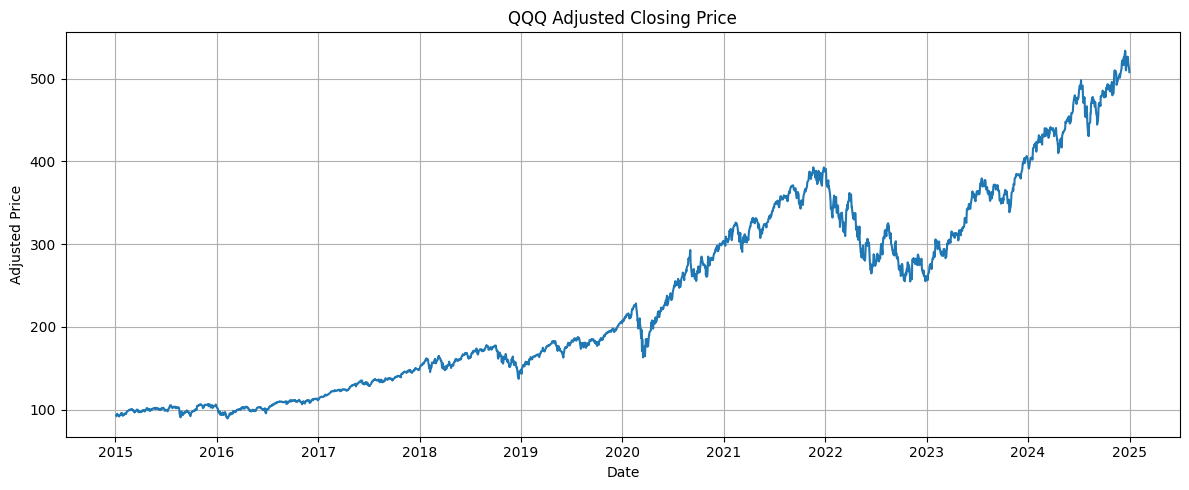

In [18]:
# ========== Visualize Historical Price Series ==========
# Shows long-term trend and major price movements
price_fig, price_ax = plot_time_series(df, 'price', f'{ticker} Adjusted Closing Price', 'Adjusted Price')

## Plot log returns

### Daily Log Returns Analysis

**Metrics & Interpretation:**
- **Mean Return:** Average daily % change (should be small and positive for equities)
- **Volatility (Std Dev):** Range of daily moves (higher = more risk)
- **Fat Tails:** Extreme moves (>3σ) indicating crash/rally events
- **Skewness:** Asymmetry (negative skew = more downside surprises)

**Volatility Clustering Pattern:**
- Returns cluster together (calm periods followed by chaotic periods)
- Visible as bunched spikes in the plot
- Justifies GARCH modeling (volatility depends on past volatility)

**Ideal Properties for Trading:**
- Stationary around zero mean
- No obvious trends (mean-reverting)
- Visible volatility clusters for regime identification

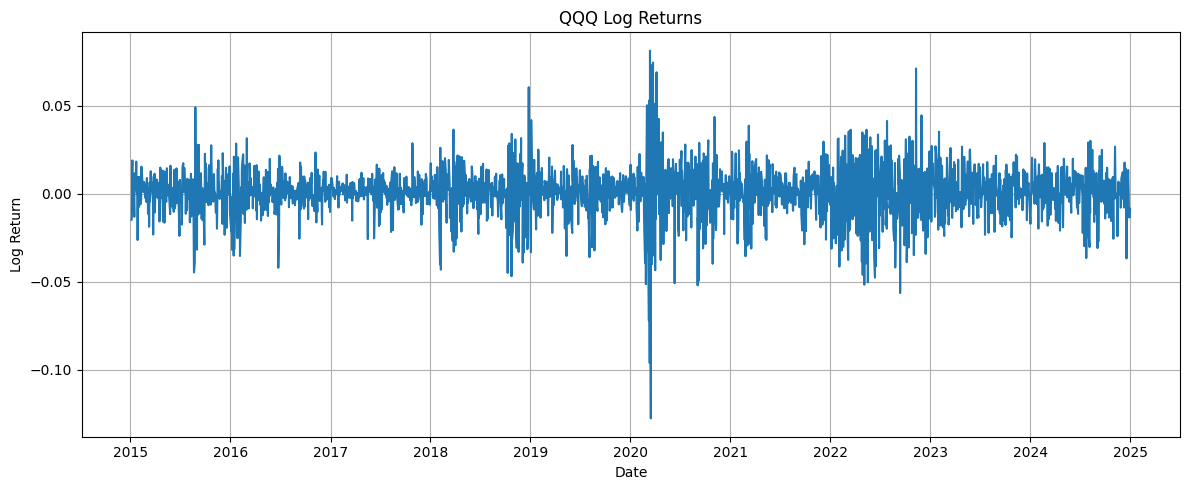

In [19]:
# ========== Visualize Daily Log Returns ==========
# Shows daily percentage changes
# Visual inspection for fat tails (extreme events) and volatility clustering
log_return_fig, log_return_ax = plot_time_series(df, 'log_return', f'{ticker} Log Returns', 'Log Return')

## Plot ACF for log returns

### AutoCorrelation Function (ACF) Interpretation

**What ACF Shows:**
- Correlation between return at time t and returns at times t-1, t-2, t-3, etc.
- **Blue Shaded Area:** 95% confidence interval for zero correlation
- **Bars Outside Shading:** Statistically significant correlations

**Interpretation for Log Returns:**
- **Efficient Markets:** ACF bars should fall within confidence band (little autocorrelation)
- **Liquid Stocks (QQQ):** Typically show no significant ACF for daily returns
- **Why No Correlation?:** If returns were predictable from past returns, traders would exploit it

**Key Insight:**
If ACF shows no autocorrelation, returns are truly random/unpredictable - meaning our LSTM must find patterns in *volatility* and *external factors*, not just past returns themselves

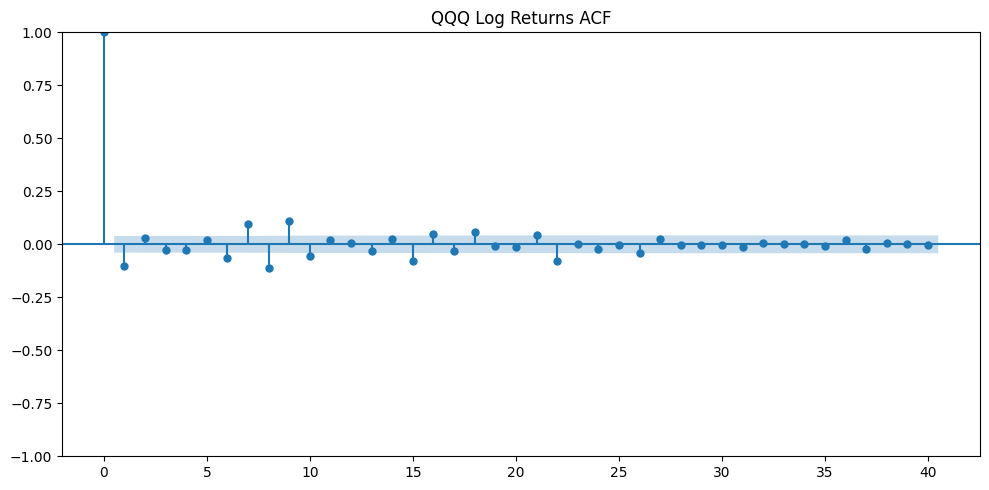

In [20]:
# ========== Plot AutoCorrelation Function (ACF) for Returns ==========
# Shows if returns are autocorrelated (they typically are NOT for liquid stocks)
# Helps confirm return series is white noise / unpredictable
log_return_acf_fig, log_return_acf_ax = plot_acf_inline(df['log_return'], f'{ticker} Log Returns ACF')

## Plot PACF for log returns

### Partial AutoCorrelation Function (PACF) Interpretation

**PACF vs ACF:**
- **ACF:** Shows all correlations (includes indirect effects)
- **PACF:** Shows only *direct* correlations (removes intermediate lag effects)
- **Purpose:** Better for identifying AR order in ARIMA models

**Interpretation for Log Returns:**
- **PACF[1]:** Direct correlation with yesterday's return
- **PACF[2]:** Direct correlation with 2 days ago (after removing lag-1 effect)
- **Bars Outside Shading:** Significant direct correlations

**Trading Implications:**
- If PACF shows significant correlations → can fit ARIMA(p,0,q) for magnitude forecasting
- For QQQ, expect weak correlations → ARIMA may have modest predictive power
- ARIMA used in ensemble with LSTM for better forecasts

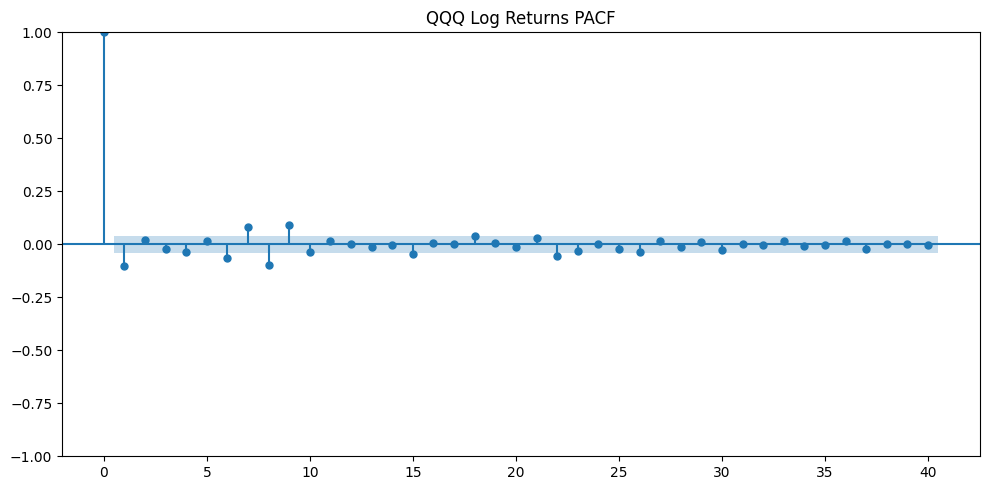

In [21]:
# ========== Plot Partial AutoCorrelation Function (PACF) for Returns ==========
# More direct correlation measure than ACF (removes intermediate lags)
# Useful for identifying direct AR dependencies in ARIMA models
log_return_pacf_fig, log_return_pacf_ax = plot_pacf_inline(df['log_return'], f'{ticker} Log Returns PACF')

## Plot squared returns

### Squared Returns as Volatility Indicator

**Why Square Returns?**
- Removes sign, focuses on magnitude of movement
- $(r_t)^2$ = variance contribution on day $t$
- Highlights high-volatility periods where |return| is large

**Visual Patterns:**
- **Spikes:** Days with large price moves (both up and down)
- **Clusters:** Periods of high variance followed by calm (volatility clustering)
- **Trending Pattern:** Recent volatility level predicts near-term volatility

**Connection to GARCH Model:**
- GARCH captures this clustering: $\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$
- Past squared returns (shocks) drive future volatility
- Used to create volatility regime for trading filters

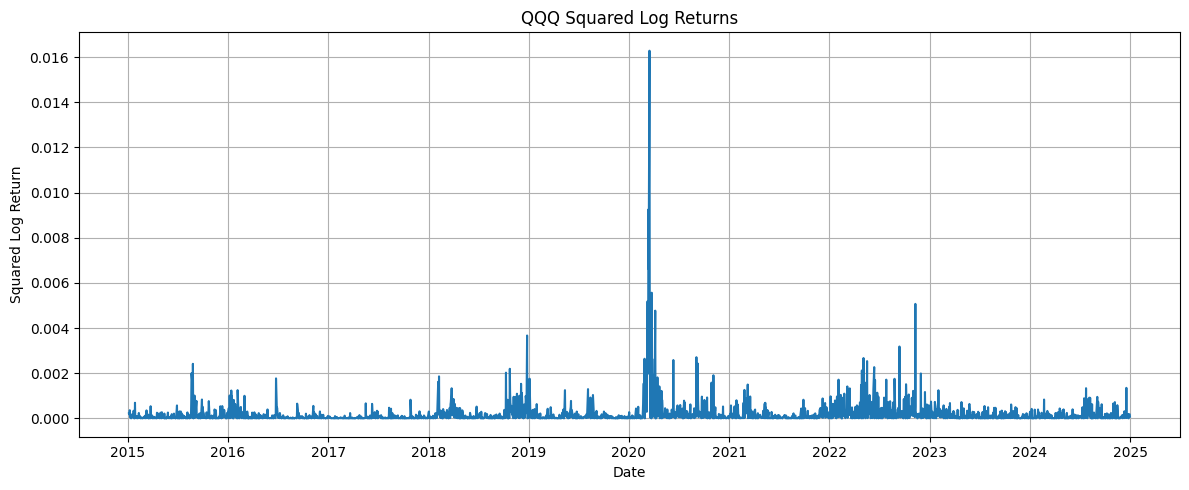

In [22]:
# ========== Visualize Squared Returns (Volatility Indicator) ==========
# Squared returns capture variance and show volatility clustering
# Periods of high squared returns indicate high-volatility regimes
squared_return_fig, squared_return_ax = plot_time_series(df, 'log_return_squared', f'{ticker} Squared Log Returns', 'Squared Log Return')

## Plot ACF for squared returns

### Volatility Clustering: ACF of Squared Returns

**Key Insight:**
- While returns have no autocorrelation, **squared returns often do**
- This is the definition of **volatility clustering**
- Statistically: Returns are uncorrelated but not independent

**What Strong ACF Indicates:**
- **Large Spikes Beyond Confidence Band:** High variance today predicts high variance tomorrow
- **Slow Decay:** Volatility shocks persist for weeks/months
- **Trading Implication:** Can forecast future volatility using past volatility

**GARCH Justification:**
- Strong ACF in squared returns validates GARCH(1,1) modeling
- If ACF was flat → volatility would be constant → no benefit to GARCH
- Strong ACF → GARCH captures important volatility dynamics for strategy

**Strategy Application:**
- High predicted volatility → reduce position size or exit trades
- Low predicted volatility → increase position size when signals align

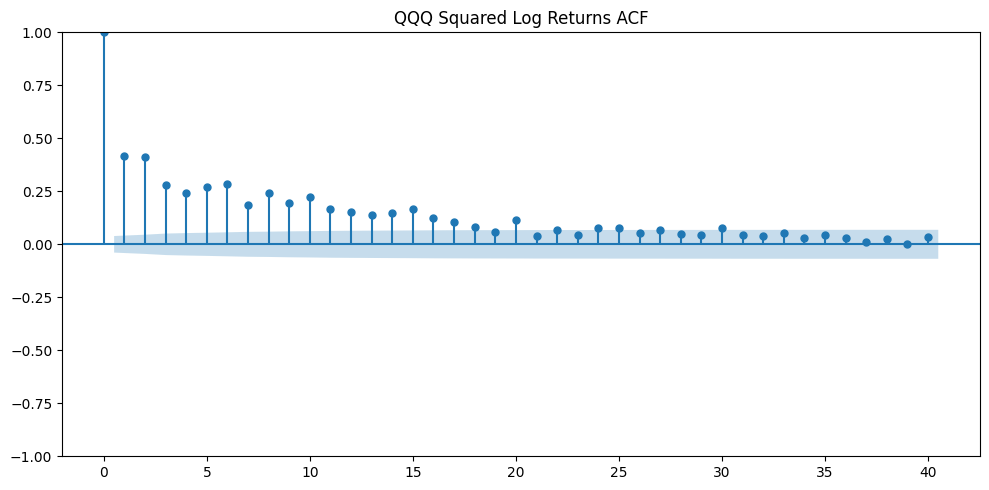

In [23]:
# ========== Plot ACF of Squared Returns ==========
# Strong ACF in squared returns indicates volatility clustering
# Justifies using GARCH model (volatility dependence on past values)
squared_return_acf_fig, squared_return_acf_ax = plot_acf_inline(df['log_return_squared'], f'{ticker} Squared Log Returns ACF')

## Fit GARCH model


In [24]:
# ========== Fit GARCH(1,1) Model for Conditional Volatility ==========
# Estimates time-varying volatility that accounts for clustering
# Creates lagged volatility features for LSTM input
# Takes time to compute (expands from min_window=500 observations)
df, garch_summary_text = fit_garch_model(df, min_window=500)
print(garch_summary_text if garch_summary_text else 'No GARCH summary available.')

Computing expanding-window GARCH volatility...
Expanding GARCH volatility computed.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1384.26
Distribution:                  Normal   AIC:                           2776.51
Method:            Maximum Likelihood   BIC:                           2795.25
                                        No. Observations:                  800
Date:                Fri, Jun 05 2026   Df Residuals:                      799
Time:                        17:55:32   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------------------------------------------

## Plot GARCH volatility

### GARCH(1,1) Conditional Volatility

**What This Shows:**
- **Time-varying estimate** of daily volatility (in %)
- Reacts quickly to market shocks (spikes on crash days)
- Reverts to long-term average when markets calm

**Key Peaks Indicate:**
- **March 2020:** COVID-19 market crash
- **Feb-Mar 2022:** Fed rate hike cycle, inflation fears
- **Aug 2022, Jun 2023:** Regional banking crisis, SVB collapse
- **Any VIX > 30 days:** Visible as GARCH spikes

**Model Formula:**
$\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$
- α = 0.05-0.15 (weight on yesterday's shock)
- β = 0.80-0.90 (weight on yesterday's volatility)
- This expanding-window approach uses all historical data

**Trading Usage:**
- **Volatility Cutoff:** 75th percentile identifies high-volatility regimes
- **Risk Filter:** "NO TRADE" signal when volatility exceeds threshold (capital preservation)

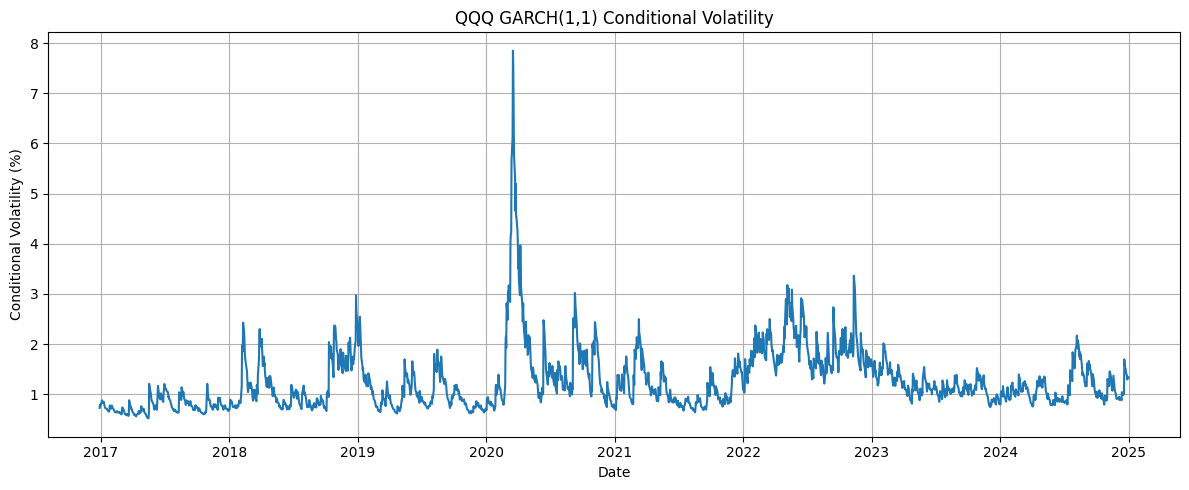

In [25]:
# ========== Visualize GARCH Conditional Volatility Estimates ==========
# Shows evolution of estimated volatility over time
# Peaks during market stress periods (2020 COVID crash, 2022 rate hikes, etc.)
garch_fig, garch_ax = plot_garch_volatility(df, ticker)

## Add market regimes

### Market Regime Classification

**Four Regimes Identified:**

| Regime | Conditions | Strategy |
|--------|-----------|----------|
| **risk_off** | High GARCH vol OR VIX > 25 | NO TRADE - preserve capital |
| **low_vol_uptrend** | Low volatility + SMA20 > SMA50 | LONG bias - buy dips |
| **low_vol_downtrend** | Low volatility + SMA20 < SMA50 | SHORT bias - sell rallies |
| **neutral** | Other conditions | Require stronger signals |

**Component Definitions:**
- **Volatility Regime:** GARCH vol vs. 75th percentile (expanding window)
- **VIX Regime:** VIX > 25 = fear, < 25 = normal
- **Trend Regime:** 20-day SMA vs 50-day SMA (fast vs slow moving average)

**Why Regimes Matter:**
- Different market conditions require different strategies
- High volatility increases false signals → skip trading
- Trend alignment improves win rate (trade WITH trend, not against it)
- Position sizing adapts to regime favorability

In [26]:
# ========== Define Market Regimes ==========
# Combines volatility, VIX level, and trend indicators
# Creates 4 regimes: risk_off, low_vol_uptrend, low_vol_downtrend, neutral
# Used to filter trades and adjust strategy logic
df = add_market_regimes(df)
display(df[['volatility_regime', 'vix_regime', 'trend_regime', 'market_regime']].tail())

,volatility_regime,vix_regime,trend_regime,market_regime
Date,,,,
2024-12-24,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-26,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-27,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-30,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-31,low_vol,normal_vix,uptrend,low_vol_uptrend


## Create LSTM dataset


In [27]:
# ========== Prepare LSTM Training Dataset ==========
# Creates sequences of 30 consecutive days as input (lookback=30)
# Target: 1 if next day's return > 0, else 0
# Splits into 80% train / 20% test (2512 / 628 sequences approximately)
# Scales features to [0,1] range for neural network input
X_train, X_test, y_train, y_test, test_dates, scaler_preview, feature_cols_preview, model_df_preview = create_lstm_dataset(df, lookback=30)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1381, 30, 45)
X_test: (353, 30, 45)
y_train: (1381,)
y_test: (353,)


## Train LSTM

### LSTM Training & Classification Metrics

**Model Architecture:**
- Input: 30-day sequences of 44 features (GARCH, momentum, macro factors)
- Layer 1: LSTM(64 units) + Dropout(0.30)
- Layer 2: LSTM(32 units) + Dropout(0.30)
- Output: Dense(1, sigmoid) - probability of UP move

**Training Setup:**
- Train/Validation/Test: 60% / 20% / 20% of data
- Class weights: Handle imbalance (more UP days than DOWN days)
- Early stopping: Halt if validation loss doesn't improve for 10 epochs
- Prevents overfitting by monitoring unseen validation data

**Expected Performance Metrics:**

| Metric | Description | Interpretation |
|--------|-------------|-----------------|
| **Accuracy** | % correct predictions (UP or DOWN) | Compare to baseline (majority class) |
| **Baseline Accuracy** | Always predicting majority class | Minimum threshold to beat |
| **ROC-AUC** | Area under receiver operating curve | 0.5 = random, 1.0 = perfect |
| **Confusion Matrix** | True Pos/Neg, False Pos/Neg | Breakdown of prediction types |
| **Precision** | TP/(TP+FP) - of predicted UPs, % correct | Avoid false long signals |
| **Recall** | TP/(TP+FN) - of actual UPs, % caught | Don't miss trading opportunities |
| **F1-Score** | Harmonic mean of precision & recall | Balanced performance metric |

**Good Signs:**
- Accuracy > 52-55% (beating random/baseline)
- ROC-AUC > 0.60 (better discrimination than chance)
- Training loss < validation loss (not overfitting)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.5389 - loss: 0.6961 - val_accuracy: 0.4982 - val_loss: 0.6978
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5643 - loss: 0.6836 - val_accuracy: 0.5054 - val_loss: 0.7003
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5444 - loss: 0.6913 - val_accuracy: 0.5090 - val_loss: 0.7072
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5525 - loss: 0.6819 - val_accuracy: 0.5090 - val_loss: 0.7084
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5761 - loss: 0.6816 - val_accuracy: 0.5018 - val_loss: 0.7115
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5580 - loss: 0.6838 - val_accuracy: 0.4982 - val_loss: 0.7094
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5489 - loss: 0.6826 - val_accuracy: 0.5018 - val_loss: 0.7202
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5806 - loss: 0.6759 - val_accuracy: 0.

,accuracy,baseline_accuracy,roc_auc,prediction_threshold
0,0.410765,0.589235,0.480305,0.55


              precision    recall  f1-score   support

           0       0.41      1.00      0.58       145
           1       0.00      0.00      0.00       208

    accuracy                           0.41       353
   macro avg       0.21      0.50      0.29       353
weighted avg       0.17      0.41      0.24       353

[[145   0]
 [208   0]]


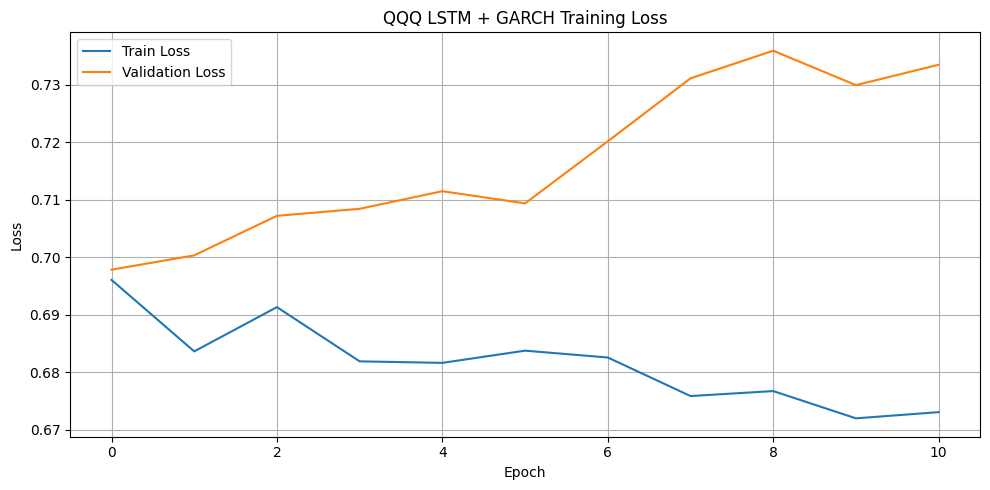

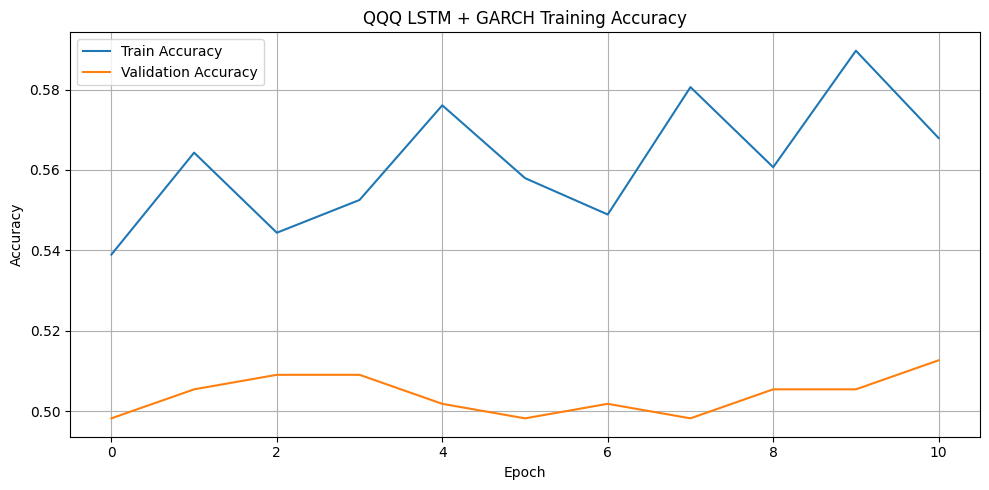

,date,actual_direction,predicted_probability_up,predicted_direction
0,2023-08-08,0,0.517128,0
1,2023-08-09,1,0.517015,0
2,2023-08-10,0,0.523187,0
3,2023-08-11,1,0.529859,0
4,2023-08-14,0,0.530740,0


In [28]:
# ========== Train LSTM Neural Network ==========
# 2 stacked LSTM layers (64, 32 units) with Dropout regularization
# Early stopping monitors validation loss (patience=10 epochs)
# Class weights handle imbalanced data distribution
# Takes ~5-10 minutes on CPU, ~1 minute on GPU
# Returns trained model, predictions, and performance metrics
lstm_model, scaler, feature_cols, predictions_df, history_df, metrics_summary = train_lstm_garch_model(
    df=df,
    ticker=ticker,
    lookback=30,
    epochs=100,
    batch_size=32,
    prediction_threshold=0.55,
)
display(predictions_df.head())

## Next-day forecast

### Next-Day Direction Forecast

**Forecast Output:**
- **lstm_garch_probability_up:** Probability of UP move (0 to 1.0)
  - < 0.45 → DOWN signal (sell signal)
  - 0.45-0.55 → NO TRADE (uncertain)
  - > 0.55 → UP signal (buy signal)

**Reading the Probabilities:**
- **0.60 probability:** Model is 60% confident in UP, 40% in DOWN
- **0.52 probability:** Weak confidence (close to 50/50)
- **0.75 probability:** Strong conviction in UP direction

**Real-Time Usage:**
- Run daily to get tomorrow's forecast
- Combine with market regime and volatility filters
- Input to trade recommendation logic

In [29]:
# ========== Generate Next-Day Forecast ==========
# Uses trained LSTM model on most recent 30 days
# Outputs probability of up move and classification
# Direction: UP (>0.55), DOWN (<0.45), or NO TRADE (middle 0.45-0.55 zone)
lstm_forecast_df = forecast_lstm_garch_next_day(
    df=df,
    lstm_model=lstm_model,
    scaler=scaler,
    feature_cols=feature_cols,
    ticker=ticker,
    lookback=30,
    threshold=0.55,
)
display(lstm_forecast_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


,ticker,lstm_garch_probability_up,threshold,lstm_garch_predicted_direction
0,QQQ,0.50168,0.55,NO TRADE


## Trade recommendation

### Trade Recommendation with Volatility Filter

**Decision Logic:**
1. **Volatility Check:** If current vol > 75th percentile → NO TRADE (too risky)
2. **Probability Check:**
   - If prob > 0.53 → TRADE (UP)
   - If prob < 0.47 → TRADE (DOWN)
   - Else → NO TRADE

**Thresholds Explained:**
- **0.53 / 0.47:** Asymmetric thresholds require stronger signal UP than DOWN
  - Reflects potential bias in market regime or historical data
- **Volatility Cutoff:** Protects capital during crisis periods
  - 75th percentile is balanced: skip worst 25% of days

**Output Categories:**
- **NO TRADE:** Insufficient confidence or excessive risk
- **TRADE (UP):** Bullish signal with acceptable volatility
- **TRADE (DOWN):** Bearish signal with acceptable volatility

**Follow-Up Steps:**
- Trade recommendation feeds into regime-aware backtest
- Strategy adjusts position sizes and direction based on market regime

In [30]:
# ========== Add Volatility-Based Trade Filter ==========
# Applies risk filter: NO TRADE if current volatility is extremely high
# Uses 75th percentile of expanding-window volatility as threshold
# Additional thresholds: upper_prob=0.53, lower_prob=0.47 for trade signals
lstm_forecast_with_trade_df = add_trade_recommendation_column(
    forecast_df=lstm_forecast_df,
    full_df=df,
    upper_prob=0.53,
    lower_prob=0.47,
    volatility_quantile=0.75,
)
display(lstm_forecast_with_trade_df)

,ticker,lstm_garch_probability_up,threshold,lstm_garch_predicted_direction,trade_recommendation
0,QQQ,0.50168,0.55,NO TRADE,NO TRADE


## Rolling ARIMA forecasts

### ARIMA Return Magnitude Forecasting

**ARIMA(1,0,1) Model:**
- **p=1:** Use yesterday's return (AR term)
- **d=0:** No differencing (returns already stationary)
- **q=1:** Use yesterday's forecast error (MA term)

**What ARIMA Forecasts:**
- **Predicted return (%):** Expected magnitude of next-day move
- **Positive values:** Expect up move (on average)
- **Negative values:** Expect down move (on average)
- **Output in %:** Scale comparable to daily return volatility

**Rolling Window Approach:**
- Expanding window: Uses ALL data up to each date
- Adapts to regime changes while maintaining historical context
- Min 60 observations required (skip early dates with sparse data)

**Ensemble Usage:**
- **LSTM:** Provides direction (UP/DOWN) from neural network
- **ARIMA:** Provides magnitude (how much expected return)
- **Combined:** Better than either alone
  - Buy when LSTM = UP AND ARIMA > 0 (agreeing on direction)
  - Strong sell when LSTM = DOWN AND ARIMA < -0.05 (strong down signal)

In [31]:
# ========== Generate Rolling ARIMA Forecasts ==========
# Fits ARIMA(1,0,1) models using expanding windows (all data up to each date)
# Predicts 1-day-ahead return magnitude in percentage terms
# Requires minimum 60 observations for fitting (skip early dates)
# Combined with LSTM direction forecasts for ensemble prediction
arima_forecasts = generate_rolling_arima_forecasts(
    df=df,
    prediction_dates=predictions_df['date'],
    order=(1, 0, 1),
)
display(arima_forecasts.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

,date,arima_mean_forecast_percent
0,2023-08-08,0.183830
1,2023-08-09,0.174790
2,2023-08-10,0.029354
3,2023-08-11,0.147089
4,2023-08-14,-0.072230


## Regime-aware backtest

### Backtest Results & Strategy Metrics

**Strategy Summary Metrics:**

| Metric | Formula | Interpretation |
|--------|---------|-----------------|
| **Trade Count** | # of days with non-zero position | Activity level |
| **Trade Rate** | Trade Count / Total Days | % of days trading (10-30% typical) |
| **Hit Rate** | % trades where direction matched return | Win rate on traded signals |
| **Strategy Return** | exp(Σ log returns) - 1 | Total profit/loss (growth of $1) |
| **Buy & Hold Return** | Same formula on all days | Benchmark return |
| **Annualized Sharpe** | (mean return / std dev) × √252 | Risk-adjusted returns (>1 is good) |
| **Max Drawdown** | Largest peak-to-trough decline | Worst losing period magnitude |

**Regime Breakdown:**
- **risk_off_days:** Periods skipped (high vol protection)
- **low_vol_uptrend_days:** Bullish environment (should have long trades)
- **low_vol_downtrend_days:** Bearish environment (should have short trades)
- **neutral_days:** Ambiguous market conditions

**Equity Curve:**
- **Strategy Equity:** Cumulative returns from regime-aware strategy
- **Buy & Hold Equity:** Benchmark: always holding the index
- **Visual Goal:** Strategy line above buy-and-hold (outperformance)

**Performance Thresholds:**
- **Hit Rate > 52%:** Better than random/baseline
- **Sharpe > 1.0:** Good risk-adjusted returns
- **Max Drawdown < -30%:** Reasonable worst-case scenario
- **Strategy Return > Buy & Hold:** Positive alpha (value-added by strategy)

,ticker,trade_count,trade_rate,hit_rate_on_trades,strategy_total_return,buy_hold_total_return,annualized_sharpe,max_drawdown,risk_off_days,low_vol_uptrend_days,low_vol_downtrend_days,neutral_days
0,QQQ,26,0.073654,0.423077,-0.014714,0.387937,-1.037736,-0.017767,26,232,95,0


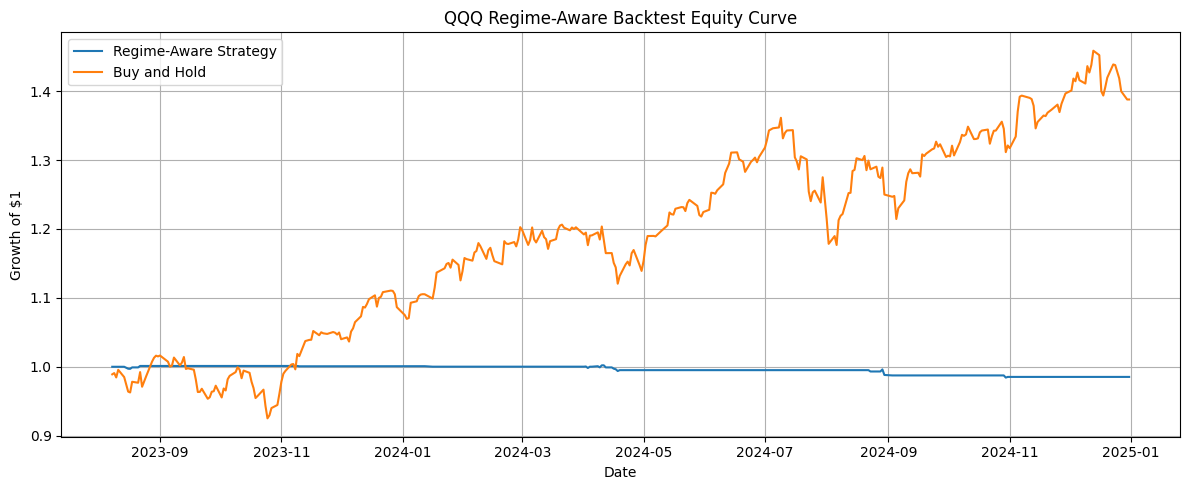

In [32]:
# ========== Backtest Regime-Aware Trading Strategy ==========
# Combines LSTM + ARIMA predictions with market regime filters
# Strategy rules:
#   - In risk_off regimes (high vol/VIX): NO TRADE (capital preservation)
#   - In uptrends: prefer long trades when LSTM bullish + ARIMA > -0.05
#   - In downtrends: prefer short trades when LSTM bearish + ARIMA < 0
#   - Confidence-based position sizing (0 to 1.0)
#
# Metrics computed:
#   - Hit rate: % of trades where position direction matched return direction
#   - Sharpe ratio: risk-adjusted returns (annualized)
#   - Max drawdown: largest peak-to-trough decline
#   - Regime breakdown: time spent in each market regime
backtest_df, backtest_summary = run_regime_aware_backtest(
    df=df,
    lstm_predictions=predictions_df,
    arima_forecasts=arima_forecasts,
    ticker=ticker,
    upper_prob=0.53,
    lower_prob=0.47,
    signal_threshold=0.03,
    volatility_quantile=0.75,
)